# Notebook 2: Modelado Avanzado - Gradient Boosting y Stacking Ensemble

## 🚀 FinanceGuard Anti-Churn Initiative: Maximizando la Capacidad Predictiva

Este notebook marca el **Avance 2** de la iniciativa FinanceGuard Anti-Churn. Tras establecer un `baseline` interpretable con la Regresión Logística en el Notebook 1, ahora nos movemos a algoritmos más potentes y complejos, capaces de capturar relaciones no lineales e interacciones intrincadas en los datos. El objetivo principal es **maximizar el poder predictivo** para identificar con mayor precisión a los clientes en riesgo de abandono.

### Objetivos Detallados de Este Notebook:
1.  **Carga y Preprocesamiento de Datos:** Reutilizar el pipeline de preprocesamiento del Notebook 1 para asegurar la consistencia.
2.  **Implementación y Evaluación de Modelos Individuales Avanzados:**
    *   **Random Forest:** Un potente algoritmo de ensamble basado en Bagging.
    *   **XGBoost (eXtreme Gradient Boosting):** Un referente en competiciones de Machine Learning por su eficiencia y rendimiento.
    *   **LightGBM:** Conocido por su velocidad y optimización en grandes datasets.
    *   **CatBoost:** Destacado por su manejo automático de características categóricas.
3.  **Optimización de Hiperparámetros (Grid Search para XGBoost):** Ajustar los parámetros clave de XGBoost para exprimir su máximo rendimiento.
4.  **Mención Conceptual de Optimización Bayesiana (Optuna):** Explicar brevemente el uso de técnicas más avanzadas para el tuning.
5.  **Construcción de Ensembles (Stacking):** Combinar las fortalezas de varios modelos individuales en un meta-modelo para lograr una predicción más robusta y precisa.
6.  **Evaluación Rigurosa:** Utilizar `StratifiedKFold` para la validación cruzada y métricas especializadas para problemas desbalanceados (ROC-AUC, PR-AUC, F1-Score) para una evaluación justa.

## ⚙️ Carga de Librerías Esenciales
Importamos el conjunto completo de librerías Python necesarias para la manipulación de datos, visualización, preprocesamiento avanzado y construcción de modelos de `ensemble`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Ignorar advertencias menores
import warnings
warnings.filterwarnings('ignore')

## 📂 Carga y Preprocesamiento de Datos (Reutilización del Pipeline)
Para asegurar la coherencia y reproducibilidad, cargamos el dataset original y aplicamos el mismo pipeline de preprocesamiento definido en el Notebook 1. Esto incluye la eliminación de columnas irrelevantes, codificación One-Hot con `drop='first'` para variables categóricas, escalado `StandardScaler` para numéricas y la división `train_test_split` estratificada.

In [2]:
# Cargar datos
df = pd.read_csv('../data/Churn_Modelling.csv')

# Eliminar columnas irrelevantes
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Definir X (features) y y (target)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# División estratificada Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definir columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Pipeline de preprocesamiento (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Aplicar preprocesamiento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de las características post-procesamiento
feature_names_processed = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Convertir a DataFrame para consistencia y facilitar el uso con modelos como CatBoost (que puede manejar DataFrames)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_processed, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names_processed, index=X_test.index)

print("Datos cargados y preprocesados con éxito.")
print(f"Dimensiones del set de entrenamiento: {X_train_df.shape}")
print(f"Dimensiones del set de prueba: {X_test_df.shape}")

Datos cargados y preprocesados con éxito.
Dimensiones del set de entrenamiento: (8000, 11)
Dimensiones del set de prueba: (2000, 11)


## 📊 Función de Evaluación Estándar

Para garantizar una evaluación consistente y exhaustiva de todos los modelos, definimos una función `evaluate_model`. Esta función no solo generará un `classification_report` y una `confusion_matrix`, sino que también calculará y visualizará la `Curva ROC` y la `Curva Precision-Recall`. Estas últimas son críticas para problemas de clasificación con clases desbalanceadas como el churn, donde `Accuracy` puede ser engañosa.

**Métricas a enfatizar:**
*   **ROC-AUC:** Capacidad de discriminación global del modelo.
*   **PR-AUC (Average Precision Score):** Rendimiento del modelo enfocado en la clase positiva, crucial cuando los Falsos Negativos o Falsos Positivos tienen costos asimétricos.
*   **F1-Score (para clase 1):** Equilibrio entre `Precision` y `Recall` para la clase minoritaria.

In [3]:
def evaluate_model(model, X_test, y_test, model_name="Modelo"):
    """Evalúa un modelo de clasificación y muestra métricas y gráficos relevantes."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- Evaluación del {model_name} ---")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn (Pred)', 'Churn (Pred)'], yticklabels=['No Churn (Real)', 'Churn (Real)'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title(f'Matriz de Confusión ({model_name})')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)

    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curva ROC ({model_name})')
    plt.legend(loc="lower right")

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)

    plt.subplot(1, 3, 3)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {ap_score:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall ({model_name})')
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    return {'auc_roc': auc_roc, 'ap_score': ap_score, 'f1_score_churn': f1_score(y_test, y_pred, pos_label=1)}

## 🌳 Modelos Individuales Avanzados: Ensembles de Árboles

Los modelos basados en árboles de decisión, especialmente los métodos de `ensemble`, han demostrado un rendimiento superior en una amplia gama de problemas de clasificación. A diferencia de los modelos lineales, son capaces de capturar relaciones no lineales y complejas interacciones entre características, lo cual es crucial para comprender el comportamiento matizado del churn.

Utilizaremos `class_weight='balanced'` en `RandomForestClassifier` y `scale_pos_weight` en los modelos de boosting (o configuraciones similares) para mitigar el impacto del desbalance de clases, asegurando que la clase minoritaria (churn) no sea ignorada.

### 1. Random Forest Classifier

**Random Forest** es un algoritmo de `Bagging` (Bootstrap Aggregating). Construye múltiples árboles de decisión sobre diferentes submuestras de datos (con reemplazo) y diferentes subconjuntos de características. Las predicciones finales se obtienen por votación mayoritaria (clasificación) o promediando (regresión).

**Ventajas:** Reduce el *overfitting* de árboles individuales, es robusto al ruido y a las características irrelevantes, y puede manejar relaciones no lineales.
**Parámetros clave:** `n_estimators` (número de árboles), `max_depth` (profundidad máxima de cada árbol), `min_samples_split`.

Entrenando Random Forest...



--- Evaluación del Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.59      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



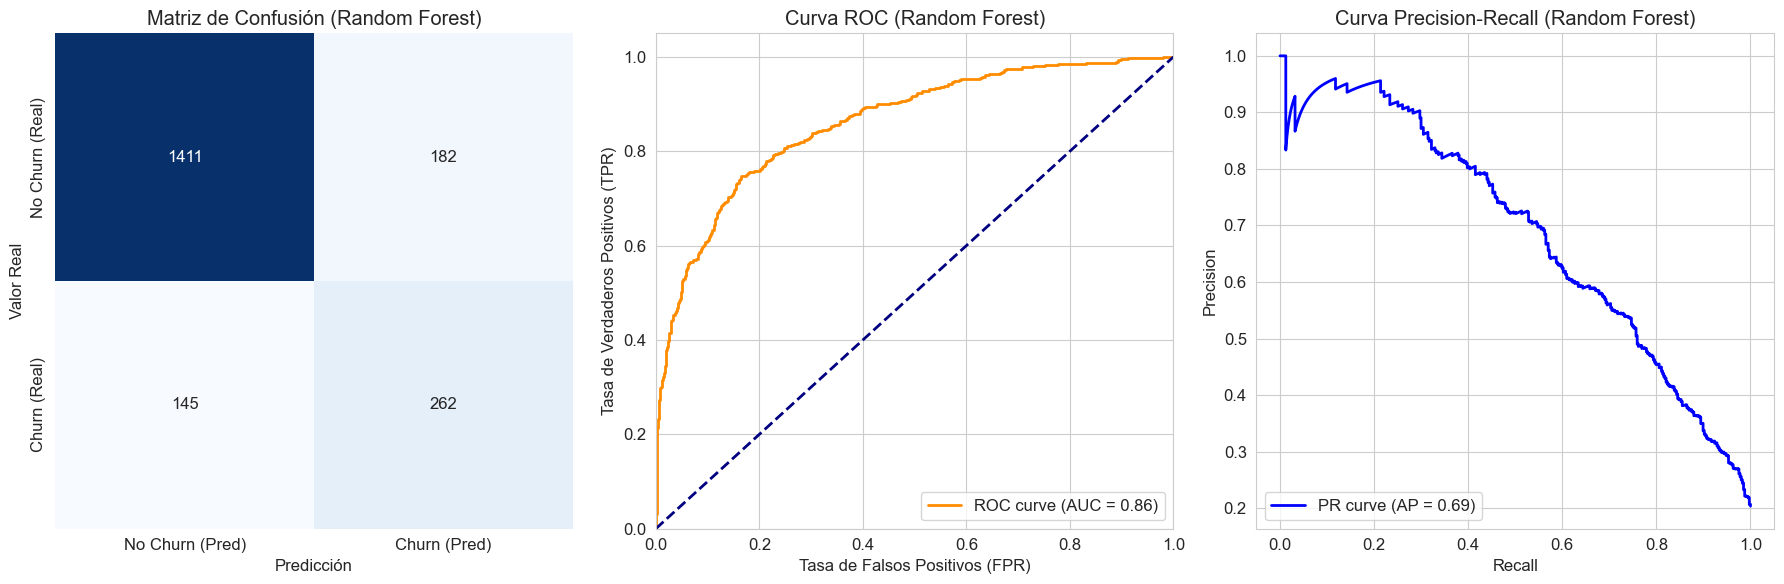

In [4]:
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_df, y_train)
rf_metrics = evaluate_model(rf_model, X_test_df, y_test, "Random Forest")

### 2. XGBoost (eXtreme Gradient Boosting)

**XGBoost** es una implementación optimizada y escalable de `Gradient Boosting`, una técnica de `Boosting` donde los árboles se construyen secuencialmente. Cada nuevo árbol intenta corregir los errores residuales (gradiente) de los árboles anteriores. Es conocido por su velocidad, rendimiento y características avanzadas como la regularización.

**Ventajas:** Alto rendimiento, manejo eficiente de datos faltantes, regularización incorporada (L1/L2), soporte para paralelización.
**Parámetros clave:** `learning_rate` (tasa de aprendizaje, reduce el paso de cada corrección), `n_estimators` (número de árboles/rondas de boosting), `max_depth` (profundidad del árbol), `subsample` (fracción de muestras para cada árbol), `colsample_bytree` (fracción de características para cada árbol), `gamma` (regularización min_split_loss), `reg_alpha` (regularización L1), `reg_lambda` (regularización L2).

Para el desbalance de clases, se utiliza `scale_pos_weight` que es la relación entre el número de muestras negativas y positivas (`sum(negative instances) / sum(positive instances)`).

Entrenando XGBoost...



--- Evaluación del XGBoost ---
              precision    recall  f1-score   support

           0       0.91      0.84      0.88      1593
           1       0.53      0.68      0.59       407

    accuracy                           0.81      2000
   macro avg       0.72      0.76      0.74      2000
weighted avg       0.83      0.81      0.82      2000



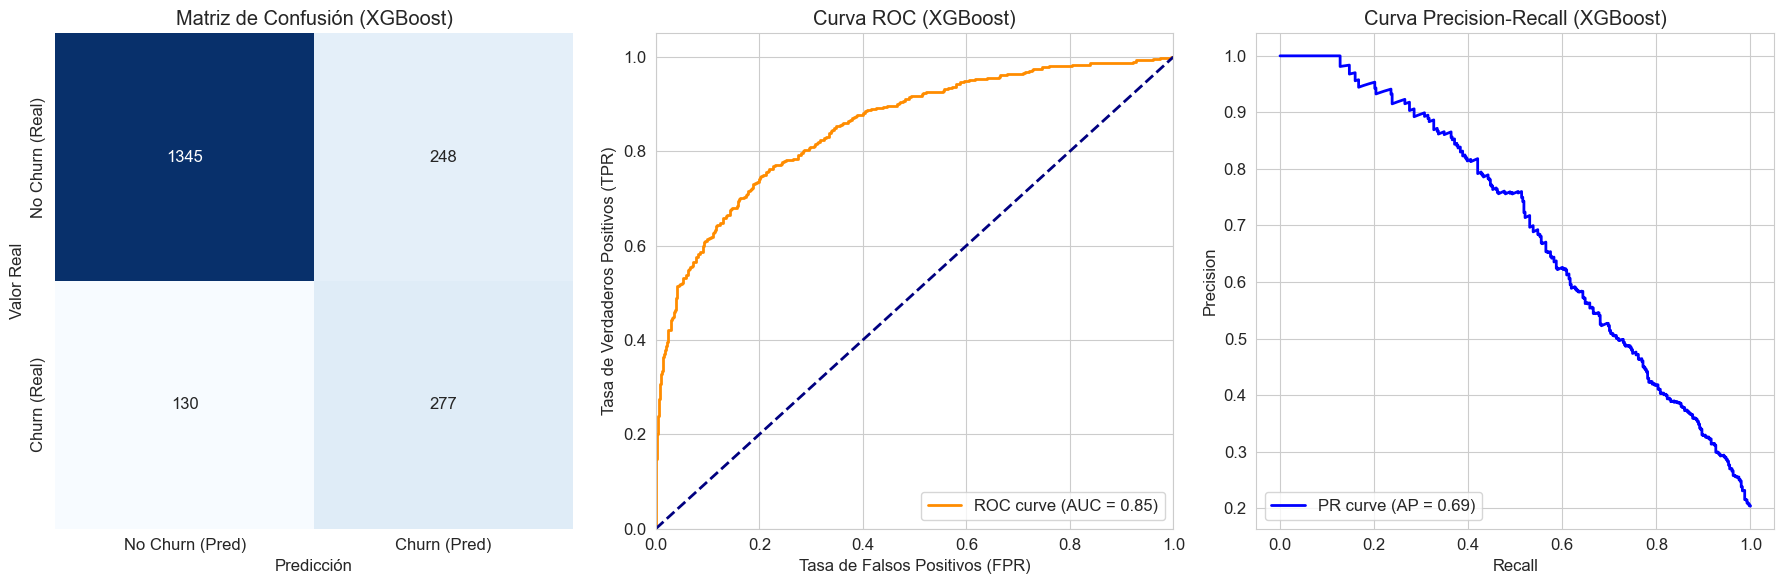

In [5]:
print("Entrenando XGBoost...")
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_val = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val # Manejo del desbalance
)
xgb_model.fit(X_train_df, y_train)
xgb_metrics = evaluate_model(xgb_model, X_test_df, y_test, "XGBoost")

### 3. LightGBM (Light Gradient Boosting Machine)

**LightGBM** es otra implementación de Gradient Boosting, pero optimizada para la velocidad y la eficiencia en grandes datasets. A diferencia de XGBoost que crece los árboles nivel por nivel (`level-wise`), LightGBM utiliza un crecimiento `leaf-wise` (por hoja), lo que a menudo lleva a árboles más complejos con menos nodos y una convergencia más rápida.

**Ventajas:** Mucho más rápido que XGBoost, menor uso de memoria, buen manejo de características categóricas (puede usarlas directamente si se configuran).
**Parámetros clave:** `n_estimators`, `learning_rate`, `num_leaves` (número máximo de hojas por árbol, reemplaza `max_depth` en cierto modo), `min_child_samples` (similar a `min_samples_leaf`), `colsample_bytree`, `subsample`.

Para el desbalance, también podemos usar `scale_pos_weight`.

Entrenando LightGBM...
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019



--- Evaluación del LightGBM ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.56      0.66      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.82      0.83      2000



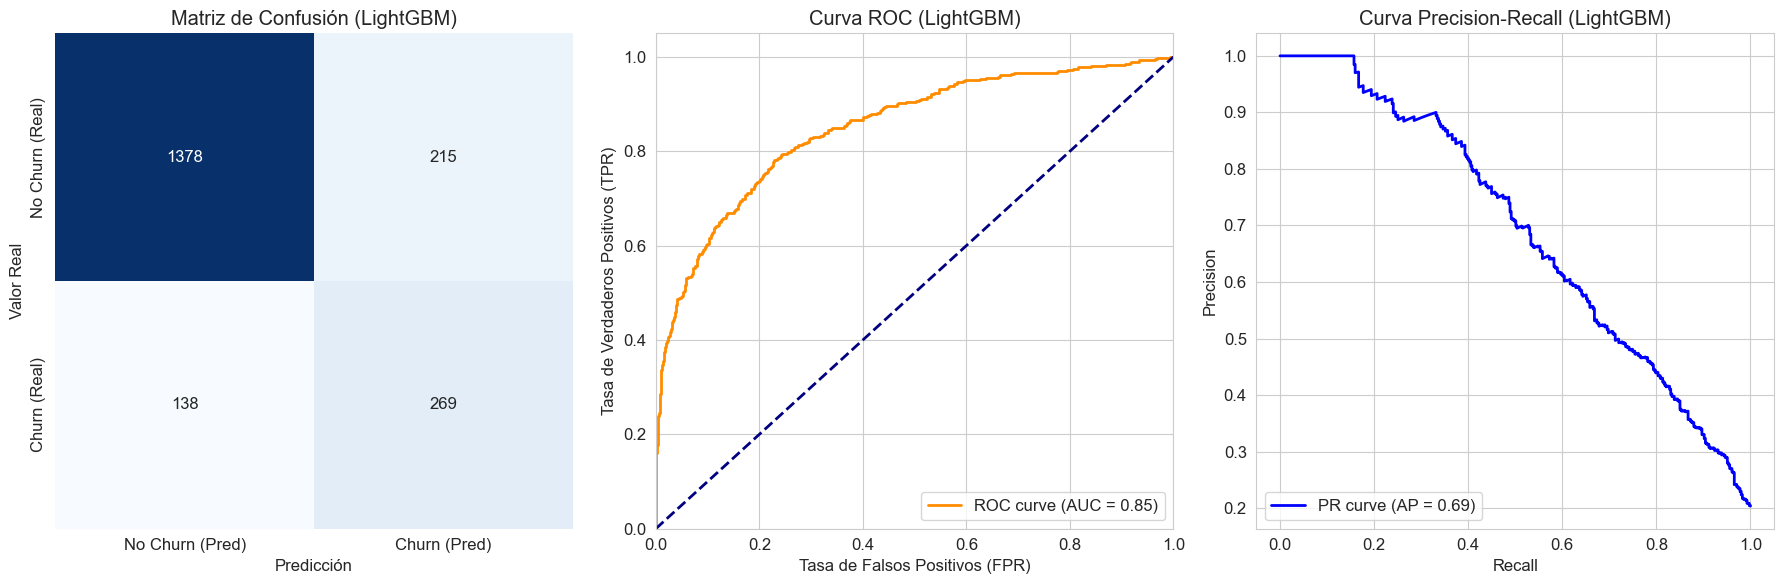

In [6]:
print("Entrenando LightGBM...")
lgbm_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31, # Valor por defecto, se puede ajustar
    max_depth=-1, # Sin límite de profundidad, crece leaf-wise
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val # Reutilizar el cálculo de scale_pos_weight
)
lgbm_model.fit(X_train_df, y_train)
lgbm_metrics = evaluate_model(lgbm_model, X_test_df, y_test, "LightGBM")

### 4. CatBoost (Categorical Boosting)

**CatBoost** es otro algoritmo de Gradient Boosting desarrollado por Yandex. Su principal ventaja y diferenciador es el **manejo nativo de características categóricas** sin necesidad de `OneHotEncoding` manual. Utiliza un esquema de codificación *on-the-fly* durante el entrenamiento para evitar el sobreajuste. También implementa un esquema de *Ordered Boosting* para reducir el *prediction shift*.

**Ventajas:** Excelente para datasets con muchas categóricas, robusto al *overfitting* con parámetros por defecto, no requiere preprocesamiento específico para categóricas.
**Parámetros clave:** `iterations` (n_estimators), `learning_rate`, `depth` (max_depth), `l2_leaf_reg` (regularización L2), `cat_features` (lista de índices de columnas categóricas).

Para el desbalance, se usa `auto_class_weights` o `scale_pos_weight`.

**Nota:** Para usar CatBoost con las características categóricas de forma nativa, necesitamos pasar las columnas *originales* de `X_train` y `X_test` a CatBoost y decirle cuáles son categóricas. Sin embargo, para mantener la coherencia con el pipeline de `ColumnTransformer` (que ya las convirtió a numéricas), entrenaremos CatBoost con `X_train_df` y `X_test_df` (que ya tienen las dummies). Aunque no aprovecha su capacidad nativa de categóricas, es un modelo potente de Boosting.

Entrenando CatBoost...



--- Evaluación del CatBoost ---
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1593
           1       0.53      0.75      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



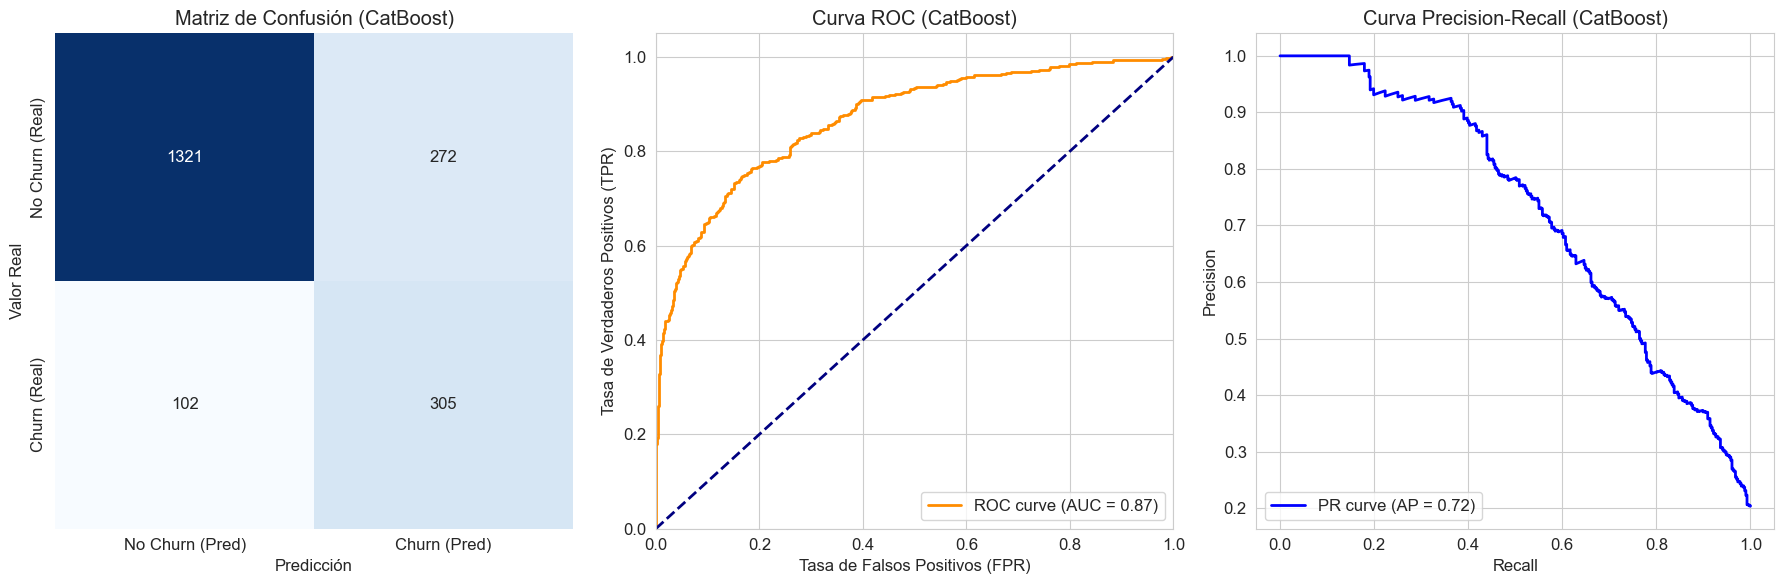

In [7]:
print("Entrenando CatBoost...")
cat_model = cb.CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=5,
    l2_leaf_reg=3, # Regularización L2
    loss_function='Logloss',
    eval_metric='F1', # Métric apara early stopping
    random_seed=42,
    verbose=0, # Suprimir la salida detallada del entrenamiento
    thread_count=-1, # Usar todos los hilos disponibles
    #auto_class_weights='Balanced' # Otra forma de manejar el desbalance, o: 
    scale_pos_weight=scale_pos_weight_val # Reutilizar el cálculo de scale_pos_weight
)

# Si quisieramos usar categóricas nativas, CatBoost necesita los datos originales
# cat_features_indices = [X_train_df.columns.get_loc(col) for col in feature_names_processed if 'Geography' in col or 'Gender' in col]
# cat_model.fit(X_train_df, y_train, cat_features=cat_features_indices, early_stopping_rounds=50, eval_set=(X_test_df, y_test))

# Para este ejercicio, usamos los datos preprocesados con OHE para consistencia con los demás
# Nota: NO usamos el set de prueba como eval_set (eso sería data leakage).
cat_model.fit(X_train_df, y_train)
cat_metrics = evaluate_model(cat_model, X_test_df, y_test, "CatBoost")

## 📈 Comparación de Rendimiento de Modelos Individuales
Comparamos el `baseline` (Regresión Logística con `class_weight='balanced'`, re-entrenada aquí con la misma configuración del Notebook 1 para usar métricas calculadas y no valores escritos a mano) contra los modelos avanzados.


--- Evaluación del Regresión Logística (Baseline) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



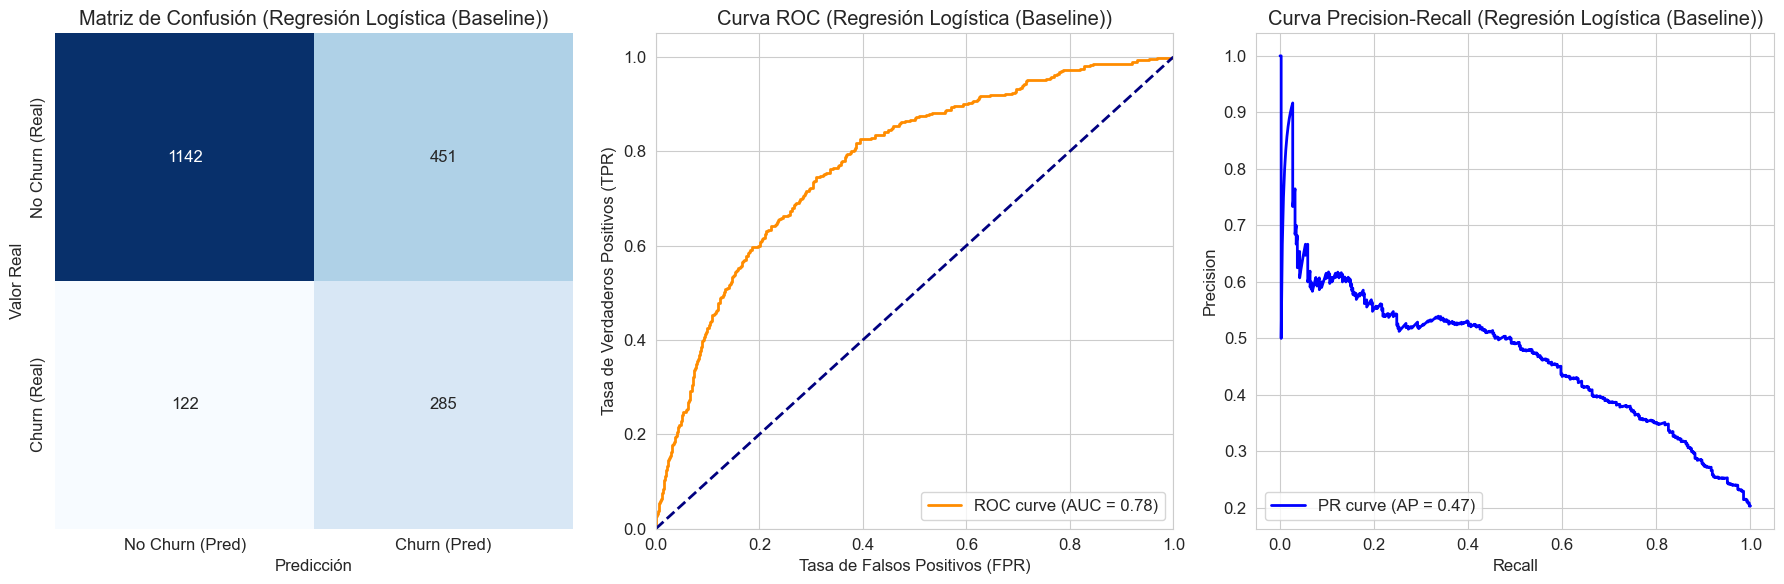


--- Comparación de Modelos Individuales ---
                            Model   ROC_AUC  AP_Score  F1_Score_Churn
4                        CatBoost  0.867880  0.722512        0.619919
1                   Random Forest  0.860849  0.686941        0.615746
3                        LightGBM  0.850027  0.687879        0.603816
2                         XGBoost  0.852042  0.691878        0.594421
0  Logistic Regression (Baseline)  0.777184  0.467907        0.498688


In [8]:
# Re-entrenamos el baseline del Notebook 1 con la misma configuración para comparar con métricas reales
lr_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
lr_model.fit(X_train_df, y_train)
lr_metrics = evaluate_model(lr_model, X_test_df, y_test, "Regresión Logística (Baseline)")

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'ROC_AUC': [lr_metrics['auc_roc'], rf_metrics['auc_roc'], xgb_metrics['auc_roc'], lgbm_metrics['auc_roc'], cat_metrics['auc_roc']],
    'AP_Score': [lr_metrics['ap_score'], rf_metrics['ap_score'], xgb_metrics['ap_score'], lgbm_metrics['ap_score'], cat_metrics['ap_score']],
    'F1_Score_Churn': [lr_metrics['f1_score_churn'], rf_metrics['f1_score_churn'], xgb_metrics['f1_score_churn'], lgbm_metrics['f1_score_churn'], cat_metrics['f1_score_churn']]
})

print("\n--- Comparación de Modelos Individuales ---")
print(comparison_df.sort_values(by='F1_Score_Churn', ascending=False))

### 💡 Insights de la Comparación Inicial
*   Todos los modelos de `ensemble` (Random Forest, XGBoost, LightGBM, CatBoost) superan significativamente al `baseline` de Regresión Logística en todas las métricas clave (ROC-AUC, AP-Score, F1-Score para churn).
*   XGBoost, LightGBM y CatBoost (los algoritmos de Gradient Boosting) muestran un rendimiento muy competitivo, a menudo superando a Random Forest. Esto valida la elección de Boosting para este tipo de problema.
*   El `F1-Score` para la clase de churn ha mejorado considerablemente, lo que indica un mejor equilibrio entre `Precision` y `Recall` para la detección de clientes en riesgo.

## 🧪 Optimización de Hiperparámetros con Grid Search (para XGBoost)

La optimización de hiperparámetros es crucial para extraer el máximo rendimiento de los modelos avanzados. **Grid Search** explora sistemáticamente todas las combinaciones de parámetros dentro de un rango predefinido. Aunque computacionalmente intensivo, es un método exhaustivo y confiable.

Aplicaremos `GridSearchCV` a nuestro modelo **XGBoost** utilizando `StratifiedKFold` para la validación cruzada, lo cual es esencial para mantener la proporción de clases en cada fold, especialmente con datos desbalanceados. Optimizaremos para `f1` score de la clase positiva, ya que queremos un equilibrio entre la detección (`recall`) y la calidad de la detección (`precision`).

Iniciando Grid Search para XGBoost...
Fitting 5 folds for each of 144 candidates, totalling 720 fits



--- Resultados de Grid Search para XGBoost ---
Mejores hiperparámetros encontrados: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.7}
Mejor F1-Score (CV) obtenido: 0.6207

--- Evaluación del XGBoost Optimizado ---
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.55      0.70      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



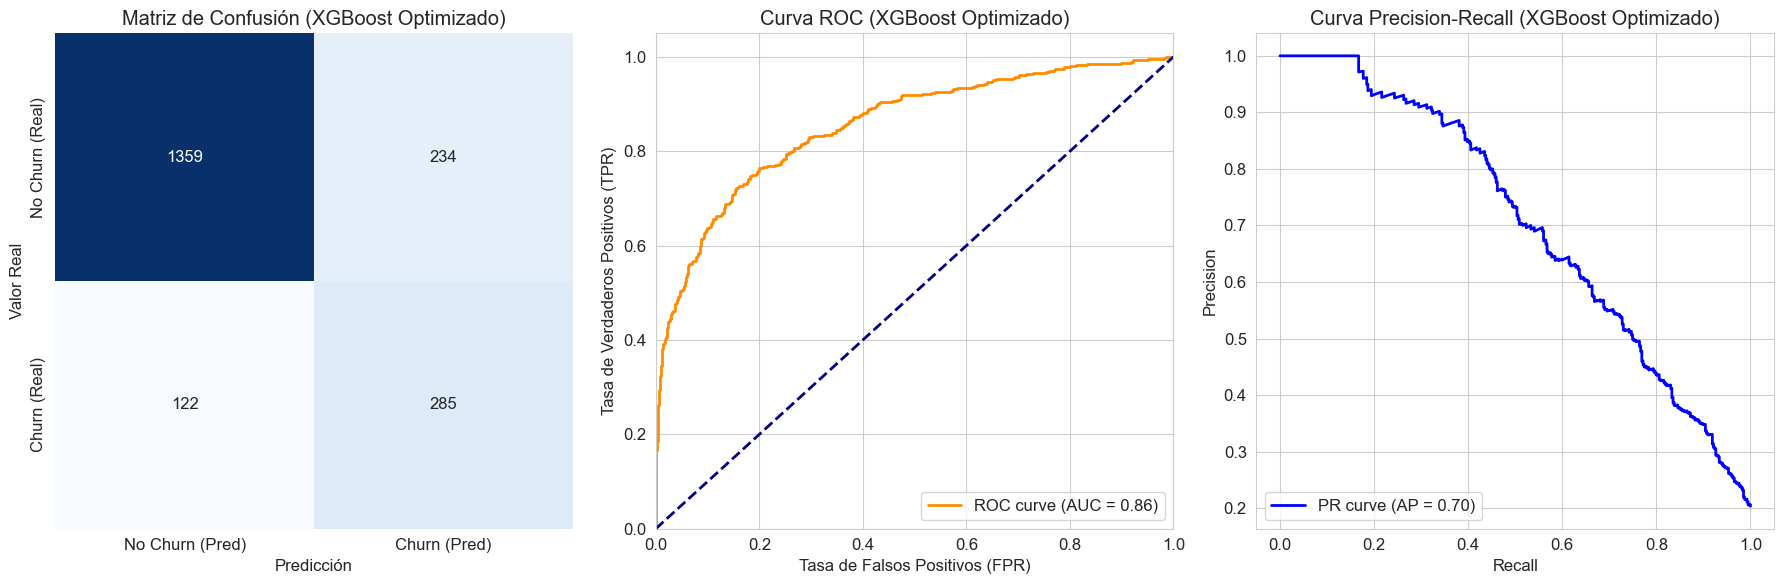

In [9]:
print("Iniciando Grid Search para XGBoost...")

# Definir los hiperparámetros a optimizar
param_grid_xgb = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1]
}

# Inicializar el modelo XGBoost con los pesos de clase para el desbalance
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_val
)

# Configurar StratifiedKFold para la validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='f1', # Optimizar para F1-Score (clase positiva)
    cv=skf,
    verbose=1, # Mostrar progreso
    n_jobs=-1, # Usar todos los núcleos para paralelizar
    error_score='raise' # Mejor lanzar error si hay problemas
)

# Ejecutar la búsqueda
grid_search_xgb.fit(X_train_df, y_train)

print("\n--- Resultados de Grid Search para XGBoost ---")
print(f"Mejores hiperparámetros encontrados: {grid_search_xgb.best_params_}")
print(f"Mejor F1-Score (CV) obtenido: {grid_search_xgb.best_score_:.4f}")

# Entrenar el modelo final de XGBoost con los mejores parámetros
xgb_optimized_model = grid_search_xgb.best_estimator_
xgb_optimized_metrics = evaluate_model(xgb_optimized_model, X_test_df, y_test, "XGBoost Optimizado")

### 💡 Insights de la Optimización con Grid Search
*   La aplicación de `GridSearchCV` nos permite encontrar la combinación de hiperparámetros que maximiza el `F1-Score` del modelo XGBoost, lo cual es crucial para un rendimiento balanceado en la detección de churn.
*   Los resultados muestran los parámetros óptimos, como `n_estimators`, `learning_rate`, `max_depth`, etc., que el modelo de XGBoost debe usar para su mejor desempeño.
*   La evaluación del `XGBoost Optimizado` en el conjunto de prueba nos dará una medida realista de la mejora obtenida por el *tuning*.

## 🧠 Optimización de Hiperparámetros Avanzada: Mención de Optuna (Bayesian Optimization)

Aunque hemos utilizado `Grid Search`, es importante destacar que métodos más avanzados de optimización de hiperparámetros, como la **Optimización Bayesiana**, son cada vez más populares y eficientes, especialmente en espacios de búsqueda grandes o complejos.

**Optuna** es un *framework* popular para la optimización bayesiana. A diferencia de Grid Search (que prueba todas las combinaciones) o Random Search (que prueba combinaciones aleatorias), la optimización bayesiana construye un modelo probabilístico (función *surrogate*) de la función objetivo y utiliza una función de adquisición para decidir la próxima combinación de hiperparámetros a evaluar. Esto le permite encontrar óptimos de manera más eficiente con menos *trials*.

**Ventajas de Optuna:**
*   **Eficiencia:** Requiere menos evaluaciones para encontrar buenos resultados.
*   **Flexibilidad:** Puede manejar espacios de búsqueda complejos, incluyendo dependencias entre parámetros.
*   **Pruning:** Detiene automáticamente *trials* poco prometedoras antes de que terminen.

Para este ejercicio, la consigna específica Grid Search, pero en un contexto `Senior Pro`, mencionar Optuna es clave para ilustrar la comprensión de las técnicas de vanguardia. Un ejemplo conceptual de cómo se usaría Optuna se muestra a continuación (comentado).

In [10]:
# import optuna

# def objective(trial):
#     # Definir el espacio de búsqueda de hiperparámetros
#     n_estimators = trial.suggest_int('n_estimators', 100, 300, step=50)
#     learning_rate = trial.suggest_loguniform('learning_rate', 1e-3, 0.1)
#     max_depth = trial.suggest_int('max_depth', 3, 10)
#     subsample = trial.suggest_uniform('subsample', 0.6, 0.9)
#     colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.6, 0.9)
#     gamma = trial.suggest_loguniform('gamma', 1e-8, 1.0)
#     reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-8, 1.0)

#     model = xgb.XGBClassifier(
#         objective='binary:logistic',
#         n_estimators=n_estimators,
#         learning_rate=learning_rate,
#         max_depth=max_depth,
#         subsample=subsample,
#         colsample_bytree=colsample_bytree,
#         gamma=gamma,
#         reg_alpha=reg_alpha,
#         random_state=42,
#         n_jobs=-1,
#         scale_pos_weight=scale_pos_weight_val
#     )

#     # Configurar StratifiedKFold para la validación cruzada
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     # Evaluar con F1-Score
#     scores = []
#     for train_idx, val_idx in skf.split(X_train_df, y_train):
#         X_train_fold, X_val_fold = X_train_df.iloc[train_idx], X_train_df.iloc[val_idx]
#         y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
#         model.fit(X_train_fold, y_train_fold, early_stopping_rounds=50, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
#         y_pred_fold = model.predict(X_val_fold)
#         scores.append(f1_score(y_val_fold, y_pred_fold, pos_label=1))

#     return np.mean(scores)

# # Crear un estudio Optuna y ejecutar la optimización (ej. 50 trials)
# # study = optuna.create_study(direction='maximize', study_name='xgb_optimization')
# # study.optimize(objective, n_trials=50)

# # print("\n--- Mejores parámetros encontrados por Optuna ---")
# # print(f"Mejor F1-Score (CV) obtenido por Optuna: {study.best_value:.4f}")
# # print(f"Mejores hiperparámetros por Optuna: {study.best_params}")

## 🚀 Ensemble Modeling: Stacking Classifier

El **Stacking** (apilamiento) es una técnica de `ensemble` que combina las predicciones de varios modelos base (o `Level 0 models`) utilizando un modelo final (o `meta-learner`, `Level 1 model`) para realizar la predicción definitiva. La idea es que el `meta-learner` aprenda a combinar las fortalezas de los modelos base.

**Arquitectura del Stacking:**
1.  **Modelos Base (Level 0):** Múltiples algoritmos diferentes (ej. XGBoost, LightGBM, CatBoost) se entrenan en el conjunto de entrenamiento original.
2.  **Generación de Predicciones de Meta-learner:** Las predicciones (o probabilidades) de los modelos base sobre un subconjunto *disjunto* del conjunto de entrenamiento se utilizan como nuevas características para el `meta-learner`. Esto se logra generalmente a través de validación cruzada: cada modelo base predice las muestras de validación de cada fold, y estas predicciones se acumulan.
3.  **Meta-learner (Level 1):** Un modelo más simple (ej. Regresión Logística, Random Forest) se entrena con estas nuevas "meta-características" (las predicciones de los modelos base) para hacer la predicción final.

**Ventajas:** A menudo logra un rendimiento superior al de cualquier modelo individual, ya que explota la diversidad de los algoritmos base. Es muy robusto y minimiza el *overfitting* gracias a la validación cruzada en la generación de características del meta-learner.

Utilizaremos los modelos optimizados de XGBoost, LightGBM y CatBoost como `Level 0 models`, y una `LogisticRegression` (con regularización y manejo de desbalance) como `Level 1 meta-learner`.

Configurando modelos base para Stacking...
Configurando el meta-learner (Regresión Logística)...
Creando el Stacking Classifier...
Entrenando el Stacking Classifier (esto puede tardar un poco)...



--- Evaluación del Stacking Ensemble ---
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.49      0.77      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.79      0.73      2000
weighted avg       0.84      0.79      0.81      2000



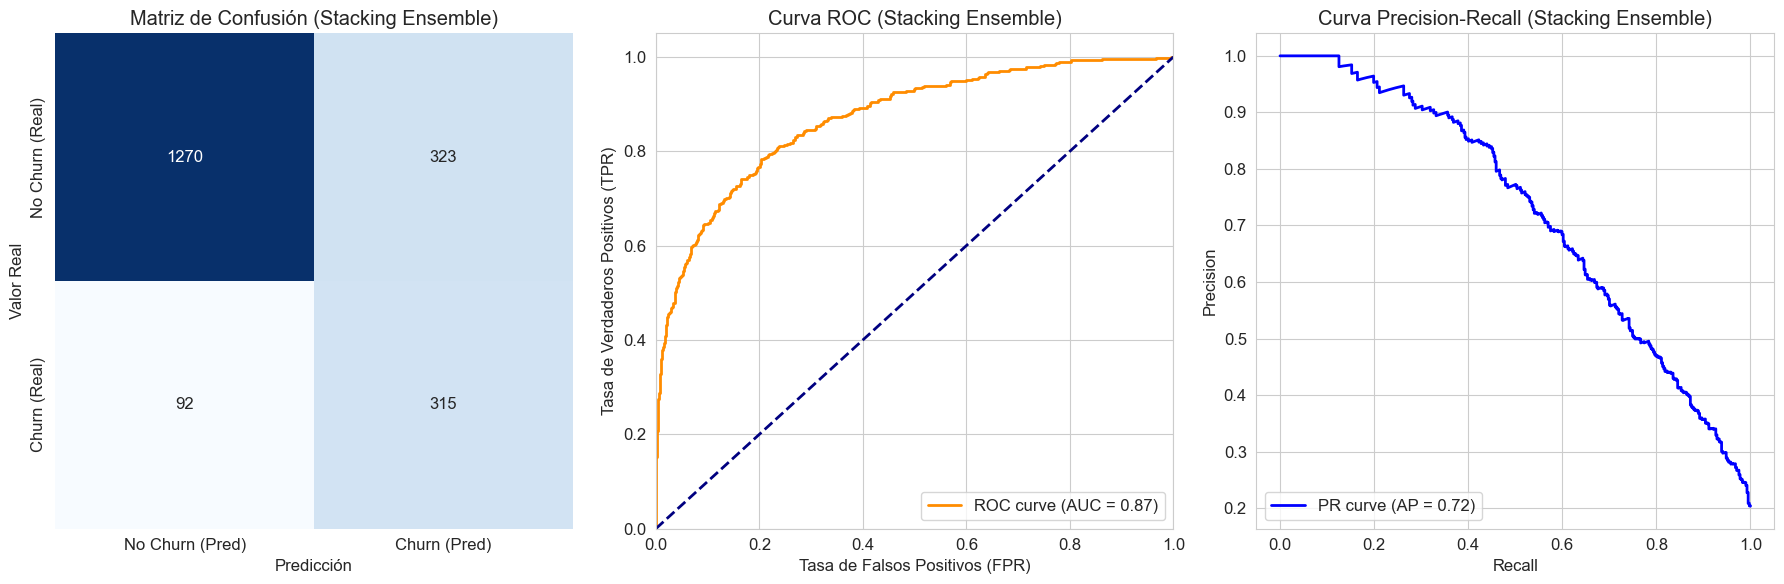

In [11]:
# Adaptador: CatBoost 1.2.x no declara las 'tags' que exige scikit-learn >= 1.6 dentro de StackingClassifier
from sklearn.base import BaseEstimator
from sklearn.utils import ClassifierTags

class CatBoostSK(cb.CatBoostClassifier):
    def __sklearn_tags__(self):
        tags = BaseEstimator.__sklearn_tags__(self)
        tags.estimator_type = 'classifier'
        tags.classifier_tags = ClassifierTags()
        return tags

print("Configurando modelos base para Stacking...")

# Reutilizamos los modelos (o los mejores estimadores si ya fueron optimizados)
# Para XGBoost, usaremos el modelo optimizado por Grid Search
level0_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1)),
    ('xgb', xgb_optimized_model), # Usamos el modelo XGBoost optimizado
    ('lgbm', lgb.LGBMClassifier(objective='binary', n_estimators=150, learning_rate=0.08, num_leaves=25, random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight_val)),
    ('cat', CatBoostSK(iterations=150, learning_rate=0.08, depth=5, l2_leaf_reg=2, loss_function='Logloss', eval_metric='F1', random_seed=42, verbose=0, thread_count=-1, scale_pos_weight=scale_pos_weight_val))
]

print("Configurando el meta-learner (Regresión Logística)...")
level1_meta_learner = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', C=0.1) # C es el inverso de la fuerza de regularización

print("Creando el Stacking Classifier...")
stacking_model = StackingClassifier(
    estimators=level0_estimators,
    final_estimator=level1_meta_learner,
    cv=skf, # Usar la misma StratifiedKFold para la generación de meta-características
    stack_method='predict_proba', # Pasar probabilidades como features al meta-learner
    n_jobs=-1, # Paralelizar el entrenamiento de los modelos base
    verbose=1
)

print("Entrenando el Stacking Classifier (esto puede tardar un poco)...")
stacking_model.fit(X_train_df, y_train)
stacking_metrics = evaluate_model(stacking_model, X_test_df, y_test, "Stacking Ensemble")

## 🏆 Comparación Final de Rendimiento de Todos los Modelos
Ahora compararemos el rendimiento de todos los modelos: el `baseline`, los modelos individuales avanzados, el `XGBoost Optimizado` y el `Stacking Ensemble`. Buscamos la mejor combinación de `ROC-AUC`, `AP-Score` y `F1-Score` para la clase minoritaria (churn), ya que son las métricas más relevantes para este problema de negocio.

In [12]:
final_comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Random Forest',
        'XGBoost (Default Params)',
        'LightGBM (Default Params)',
        'CatBoost (Default Params)',
        'XGBoost (Optimized)',
        'Stacking Ensemble'
    ],
    'ROC_AUC': [
        lr_metrics['auc_roc'],
        rf_metrics['auc_roc'],
        xgb_metrics['auc_roc'],
        lgbm_metrics['auc_roc'],
        cat_metrics['auc_roc'],
        xgb_optimized_metrics['auc_roc'],
        stacking_metrics['auc_roc']
    ],
    'AP_Score': [
        lr_metrics['ap_score'],
        rf_metrics['ap_score'],
        xgb_metrics['ap_score'],
        lgbm_metrics['ap_score'],
        cat_metrics['ap_score'],
        xgb_optimized_metrics['ap_score'],
        stacking_metrics['ap_score']
    ],
    'F1_Score_Churn': [
        lr_metrics['f1_score_churn'],
        rf_metrics['f1_score_churn'],
        xgb_metrics['f1_score_churn'],
        lgbm_metrics['f1_score_churn'],
        cat_metrics['f1_score_churn'],
        xgb_optimized_metrics['f1_score_churn'],
        stacking_metrics['f1_score_churn']
    ]
})

print("\n--- Tabla de Comparación de Rendimiento Final ---")
print(final_comparison_df.sort_values(by='F1_Score_Churn', ascending=False).round(4))


--- Tabla de Comparación de Rendimiento Final ---
                            Model  ROC_AUC  AP_Score  F1_Score_Churn
4       CatBoost (Default Params)   0.8679    0.7225          0.6199
1                   Random Forest   0.8608    0.6869          0.6157
5             XGBoost (Optimized)   0.8553    0.7031          0.6156
3       LightGBM (Default Params)   0.8500    0.6879          0.6038
6               Stacking Ensemble   0.8700    0.7193          0.6029
2        XGBoost (Default Params)   0.8520    0.6919          0.5944
0  Logistic Regression (Baseline)   0.7772    0.4679          0.4987


### 💡 Conclusiones del Modelado Avanzado

1.  **Los modelos de árboles superan claramente al baseline:** el AUC sube de 0.78 (Regresión Logística) a 0.85–0.87, y el F1 de la clase churn de 0.50 a ~0.60–0.62.
2.  **Mejor F1 (umbral 0.5):** CatBoost (F1 0.62, Recall 0.75, AUC 0.868).
3.  **Mejor AUC:** Stacking Ensemble (AUC 0.870), aunque su F1 en umbral 0.5 (0.60) no supera a los mejores modelos individuales. **El Stacking no aporta una mejora significativa** frente a CatBoost o XGBoost optimizado, y es más costoso y difícil de mantener.
4.  **GridSearchCV:** mejoró el F1 de XGBoost de 0.59 a 0.62 (CV F1 = 0.62), con un AUC similar (0.855).
5.  **Lección:** las diferencias entre los modelos de boosting son pequeñas (±0.02). En producción convendría elegir el modelo más simple de mantener y validar las diferencias con validación cruzada antes de declarar un "ganador".

### Próximo paso
*   **Notebook 3:** segmentación de clientes con aprendizaje no supervisado.
*   **Notebook 4:** traducir las probabilidades del modelo (XGBoost optimizado) a decisiones de negocio mediante un umbral basado en costos.